In [87]:
import sys
print(sys.executable)

/Users/mehedihasan/Documents/Assignment_ML/venv/bin/python


# Airline Passenger Satisfaction Analysis

Machine learning analysis using PCA and Logistic Regression to understand key drivers of airline passenger satisfaction.

## Problem Statement

Airlines collect passenger feedback on multiple service aspects such as seating comfort, onboard service, and flight delays. Understanding which factors influence passenger satisfaction can help airlines improve customer experience.

This project applies machine learning techniques to analyze airline passenger satisfaction and identify the most influential factors affecting satisfaction levels.

In [88]:
import pandas as pd
import numpy as np 

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, confusion_matrix, roc_curve, auc

from sklearn.linear_model import LinearRegression, LogisticRegression

from sklearn.decomposition import PCA 

from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.model_selection import train_test_split

from matplotlib import pyplot as plt

## Dataset Overview

In [89]:
df = pd.read_csv("/Users/mehedihasan/Downloads/airline passenger satisfaction/airline_passenger_satisfaction.csv")
print(df.head())
df.info()
df.describe()

   ID  Gender  Age Customer Type Type of Travel     Class  Flight Distance  \
0   1    Male   48    First-time       Business  Business              821   
1   2  Female   35     Returning       Business  Business              821   
2   3    Male   41     Returning       Business  Business              853   
3   4    Male   50     Returning       Business  Business             1905   
4   5  Female   49     Returning       Business  Business             3470   

   Departure Delay  Arrival Delay  Departure and Arrival Time Convenience  \
0                2            5.0                                       3   
1               26           39.0                                       2   
2                0            0.0                                       4   
3                0            0.0                                       2   
4                0            1.0                                       3   

   ...  On-board Service  Seat Comfort  Leg Room Service  Cleanlines

,ID,Age,Flight Distance,Departure Delay,Arrival Delay,Departure and Arrival Time Convenience,Ease of Online Booking,Check-in Service,Online Boarding,Gate Location,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling
count,129880.000000,129880.000000,129880.000000,129880.000000,129487.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000
mean,64940.500000,39.427957,1190.316392,14.713713,15.091129,3.057599,2.756876,3.306267,3.252633,2.976925,3.383023,3.441361,3.350878,3.286326,3.204774,3.642193,2.728696,3.358077,3.632114
std,37493.270818,15.119360,997.452477,38.071126,38.465650,1.526741,1.401740,1.266185,1.350719,1.278520,1.287099,1.319289,1.316252,1.313682,1.329933,1.176669,1.329340,1.334049,1.180025
min,1.000000,7.000000,31.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,32470.750000,27.000000,414.000000,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,2.000000,2.000000,3.000000
50%,64940.500000,40.000000,844.000000,0.000000,0.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,3.000000,3.000000,4.000000,3.000000,4.000000,4.000000
75%,97410.250000,51.000000,1744.000000,12.000000,13.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,5.000000
max,129880.000000,85.000000,4983.000000,1592.000000,1584.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


## Missing Value Investigation

In [90]:
print(df.isnull().sum())

missing_values = df[df['Arrival Delay'].isnull()]
print(missing_values)

subset = df[df["Arrival Delay"].isnull()][["Departure Delay", "Flight Distance"]]
print(subset)

ID                                          0
Gender                                      0
Age                                         0
Customer Type                               0
Type of Travel                              0
Class                                       0
Flight Distance                             0
Departure Delay                             0
Arrival Delay                             393
Departure and Arrival Time Convenience      0
Ease of Online Booking                      0
Check-in Service                            0
Online Boarding                             0
Gate Location                               0
On-board Service                            0
Seat Comfort                                0
Leg Room Service                            0
Cleanliness                                 0
Food and Drink                              0
In-flight Service                           0
In-flight Wifi Service                      0
In-flight Entertainment           

## Predicting Missing Arrival Delay using Linear Regression

In [91]:
df_known = df[df['Arrival Delay'].notnull()]
df_missing = df[df['Arrival Delay'].isnull()]

X_train = df_known[['Departure Delay', 'Flight Distance']]
Y_train = df_known["Arrival Delay"]

x_predict = df_missing[["Departure Delay", 'Flight Distance']]

model = LinearRegression()
model.fit(X_train, Y_train)

predicted_values = model.predict(x_predict)

df.loc[df_missing.index, "Arrival Delay"] = predicted_values

## Linear Regression Evaluation

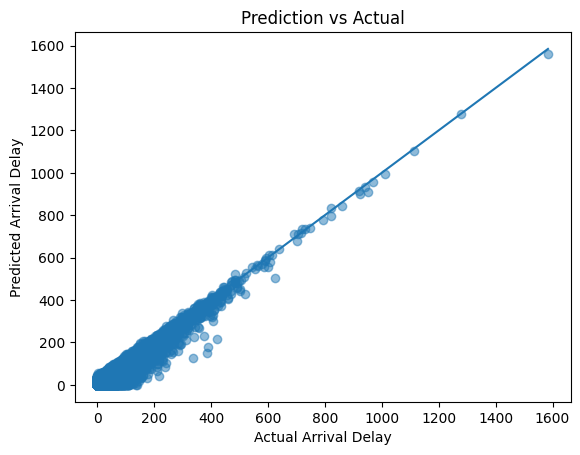

In [92]:
points = plt.scatter(Y_train, model.predict(X_train), alpha=0.5)

line_x = Y_train.min(), Y_train.max()
line_y = Y_train.min(), Y_train.max()

plt.plot(line_x, line_y)

plt.xlabel("Actual Arrival Delay")
plt.ylabel("Predicted Arrival Delay")
plt.title("Prediction vs Actual")

plt.show()

## The error matrices

In [93]:
y_predicted = model.predict(X_train)
y_true = Y_train

mae = mean_absolute_error(y_predicted, y_true)
mse = mean_squared_error(y_predicted, y_true)
r2 = r2_score(y_true, y_predicted)

print(mae, mse, r2)

5.281485361676497 100.90548237450011 0.9318019494976408


## PCA Analysis of Service Features

In [94]:
service_columns = [
"Departure and Arrival Time Convenience",
"Ease of Online Booking",
"Check-in Service",
"Online Boarding",
"Gate Location",
"On-board Service",
"Seat Comfort",
"Leg Room Service",
"Cleanliness",
"Food and Drink",
"In-flight Service",
"In-flight Wifi Service",
"In-flight Entertainment",
"Baggage Handling"
]

df_service = df[service_columns]

## Scaling Value for PCA

In [95]:
scaler = StandardScaler()

scaled = scaler.fit_transform(df_service)

## PCA

In [96]:
pca = PCA()

pc_values = pca.fit_transform(scaled)

print(pca.explained_variance_ratio_)

[0.27122716 0.16938295 0.15492849 0.07592133 0.06784607 0.04986358
 0.03836606 0.03670237 0.03344285 0.02628277 0.02348795 0.02096746
 0.01818287 0.01339807]


## PCA Visualization

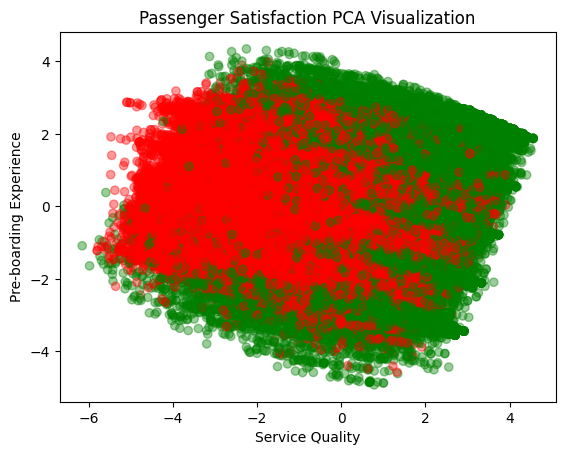

In [97]:
PC_1 = pc_values[:,0]
PC_2 = pc_values[:,1]

temp_dict = {
"Satisfied":"green",
"Neutral or Dissatisfied":"red"
}

df["satisfaction_color"] = df["Satisfaction"].map(temp_dict)

plt.scatter(PC_1, PC_2, color=df["satisfaction_color"], alpha=0.4)

plt.xlabel("Service Quality")
plt.ylabel("Pre-boarding Experience")

plt.title("Passenger Satisfaction PCA Visualization")

plt.show()

## Logistic Regression using Flight Delays

In [98]:
le = LabelEncoder()
df['target'] = le.fit_transform(df["Satisfaction"])

x = df[["Arrival Delay", "Departure Delay"]]
y = df['target']

##Split
x_train, x_test, y_train, y_test = train_test_split(
x, y, test_size=0.2, random_state=42, stratify=y
)

##Scaling

scale = StandardScaler()

train_scale = scale.fit_transform(x_train)
test_scale = scale.transform(x_test)

## Model

In [99]:
log_reg_delay = LogisticRegression()

log_reg_delay.fit(train_scale,y_train)

prediction = log_reg_delay.predict(test_scale)

## Model Evaluation with Confusion matrix

In [100]:
acc_score = accuracy_score(y_test, prediction)
cm = confusion_matrix(y_test, prediction)

print("Accuracy:", acc_score)
print(cm)

Accuracy: 0.5655220203264552
[[14690     0]
 [11286     0]]


## Final Logistic Regression Model

In [101]:
df["PC_1"] = PC_1
df["PC_2"] = PC_2

df["Customers"] = le.fit_transform(df["Customer Type"])

df = pd.get_dummies(df, columns=["Class"], drop_first=True)

###Features

X_reg = df[
["Arrival Delay","Departure Delay","PC_1","PC_2","Customers","Class_Economy","Class_Economy Plus"]
]

Y_reg = df["target"]

##Train_test division

X_reg_train, X_reg_test, Y_reg_train, Y_reg_test = train_test_split(
X_reg, Y_reg,
test_size=0.2,
random_state=42,
stratify=Y_reg
)

##Model itself

log_reg_full = LogisticRegression()

log_reg_full.fit(X_reg_train, Y_reg_train)

full_prediction = log_reg_full.predict(X_reg_test)

columns = log_reg_full.feature_names_in_

full_coeff = log_reg_full.coef_.flatten()


/Users/mehedihasan/Documents/Assignment_ML/venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Evaluation Final logistic regression model


In [102]:
final_acc_score = accuracy_score(Y_reg_test,full_prediction)
final_cm = confusion_matrix(Y_reg_test,full_prediction)
print("Model performance:",final_acc_score)
print("Confusion matrics:", final_cm)

Model performance: 0.8114413304588851
Confusion matrics: [[12576  2114]
 [ 2784  8502]]


## Coefficients Bar Chart (Plot evaluation)


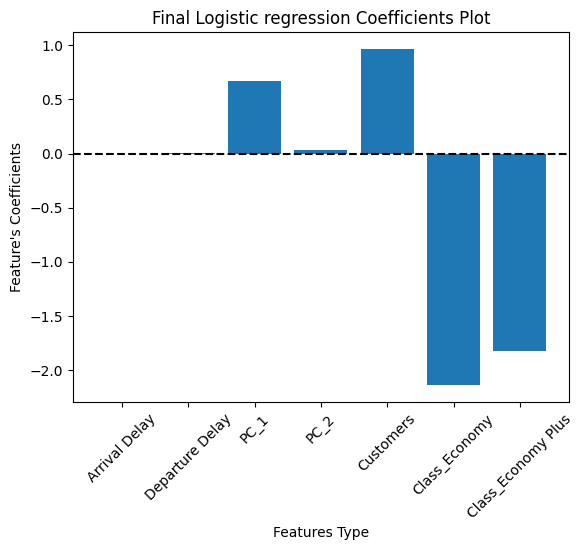

In [103]:
Final_X_values = ["Arrival Delay", 'Departure Delay', "PC_1", "PC_2", "Customers", 'Class_Economy', 'Class_Economy Plus']
Final_y_values = full_coeff
bars = plt.bar(Final_X_values, Final_y_values, 0.8)
base_line_final =plt.axhline(y=0, color="Black", linestyle='--', linewidth=1.5)
plt.xlabel("Features Type")
plt.ylabel("Feature's Coefficients")
plt.title("Final Logistic regression Coefficients Plot")
plt.xticks(rotation=45)
plt.show()

## Feature importance Ranking chart(Sorted coefficients)


In [104]:
pairs = list(zip(columns, full_coeff))
sorting_pairs = sorted(pairs, key=lambda x: x[1], reverse=True)

for f, coeff in sorting_pairs:
    print((f'{f} {round(coeff,3)}'))

Customers 0.966
PC_1 0.668
PC_2 0.03
Departure Delay 0.003
Arrival Delay -0.006
Class_Economy Plus -1.826
Class_Economy -2.138


## AUC-ROC curve for Classification model


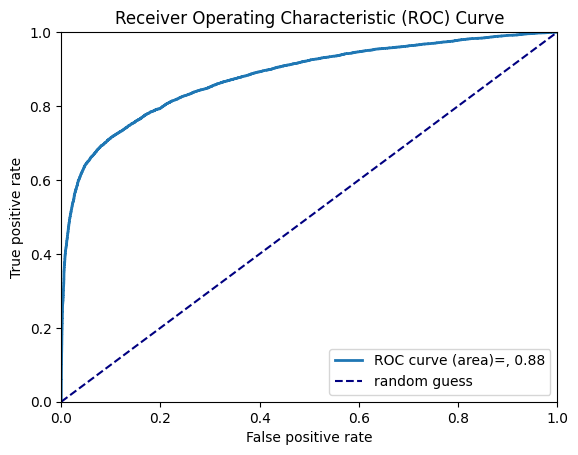

In [105]:
y_pred_prob = log_reg_full.predict_proba(X_reg_test)[:, 1]
fpr, tpr, thresholds = roc_curve(Y_reg_test, y_pred_prob)
roc_auc= auc(fpr, tpr)

## Plotting Roc curve

plt.figure()
plt.plot(fpr, tpr, lw =2, label=f'ROC curve (area)=, {roc_auc:.2f}')
plt.plot([0,1],[0,1], color="Navy", linestyle='--', label="random guess")
plt.xlim([0,1])
plt.ylim([0,1])
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend(loc="lower right")
plt.show()

## Key Findings

Flight class has the strongest influence on satisfaction
• Customer type strongly affects satisfaction probability
• Service quality factors captured by PCA significantly impact satisfaction
• Flight delays have weaker impact compared to service quality